# 作业二：基于深度学习的心电数据分类 — 实验结果可视化

统一配色方案与绘图风格，生成报告中所有图表。

**绘图规范**：每个对比实验采用 (a) mean±std 柱状图 + (b) 5-trial 散点图双视图。

In [13]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

# ---- 全局配置 ----
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
})

# ---- 统一配色 ----
C = {
    'blue':   '#4C72B0',  # DL baseline / ResNet
    'orange': '#DD8452',  # 对比组
    'green':  '#55A868',  # MLP-Mixer / RF
    'red':    '#C44E52',  # InceptionTime / heatmap
    'purple': '#8172B3',  # SE attention
    'gray':   '#937860',  # ML baseline
}
QUAD = [C['blue'], C['orange'], C['green'], C['red']]

FIG_DIR = Path('../results/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR = Path('../results/logs')

def save_fig(fig, name):
    fig.savefig(FIG_DIR / name)
    print(f'Saved: {name}')

def load_json(name):
    with open(LOG_DIR / name) as f:
        return json.load(f)

def bar_scatter(axes, names, scores_dict, means, stds, colors, title_prefix,
               ylim=None, stat_text=None):
    """统一双视图： 柱状图 + 散点图。标题分两行，统计信息放第二行。"""
    n = len(names)
    x = np.arange(n)

    # ---- 柱状图 ----
    ax = axes[0]
    bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors,
                  edgecolor='white', width=0.5)
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.001,
                f'{m:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylabel('F1-macro')
    if ylim: ax.set_ylim(ylim)
    line1 = f'{title_prefix} Mean±SD'
    if stat_text:
        ax.set_title(f'{line1}\n{stat_text}', fontsize=11)
    else:
        ax.set_title(line1)

    # ---- 散点图 ----
    ax = axes[1]
    for i, (name, color) in enumerate(zip(names, colors)):
        scores = scores_dict[name]
        xi = np.random.normal(i, 0.06, size=len(scores))
        ax.scatter(xi, scores, color=color, s=55, zorder=3,
                   edgecolors='white', linewidths=0.5, label=name)
        ax.hlines(np.mean(scores), i-0.2, i+0.2, colors=color, lw=1.5, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylabel('F1-macro')
    if ylim: ax.set_ylim(ylim)
    ax.legend(fontsize=8, ncol=min(n, 3), loc='lower right')
    ax.set_title(f'{title_prefix} Per-trial')

---
## Phase 1: DL/ML 基线对比

Saved: phase1_bars_and_scatter.png


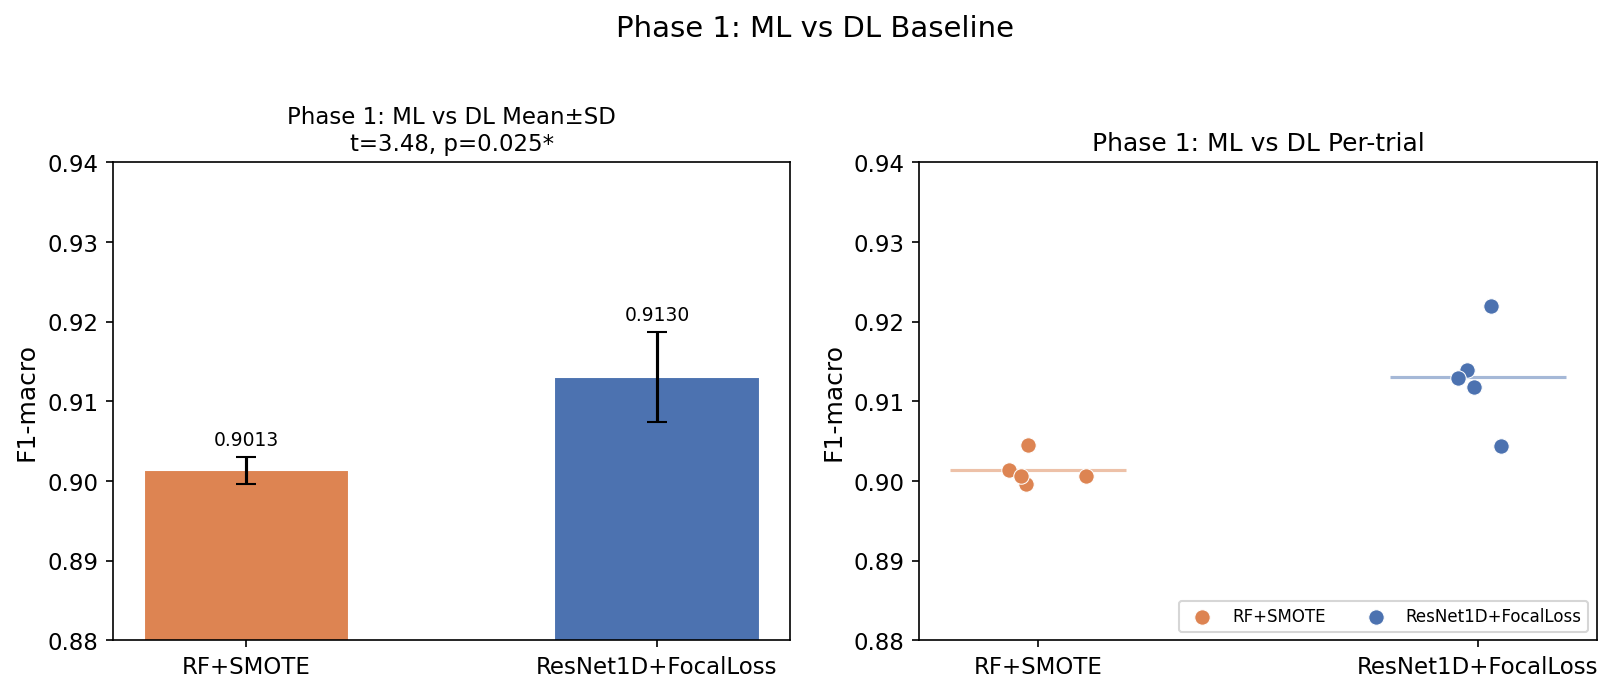

In [14]:
p1 = load_json('phase1_stats.json')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
bar_scatter(
    axes,
    names=['RF+SMOTE', 'ResNet1D+FocalLoss'],
    scores_dict={'RF+SMOTE': p1['ml_test_f1'], 'ResNet1D+FocalLoss': p1['dl_test_f1']},
    means=[p1['ml_mean'], p1['dl_mean']],
    stds=[p1['ml_std'], p1['dl_std']],
    colors=[C['orange'], C['blue']],
    title_prefix='Phase 1: ML vs DL',
    ylim=(0.88, 0.94),
    stat_text=f't={p1["t_stat"]:.2f}, p={p1["p_val"]:.3f}*',
)
fig.suptitle('Phase 1: ML vs DL Baseline', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase1_bars_and_scatter.png')
plt.show()

Saved: phase1_curve_and_cm.png


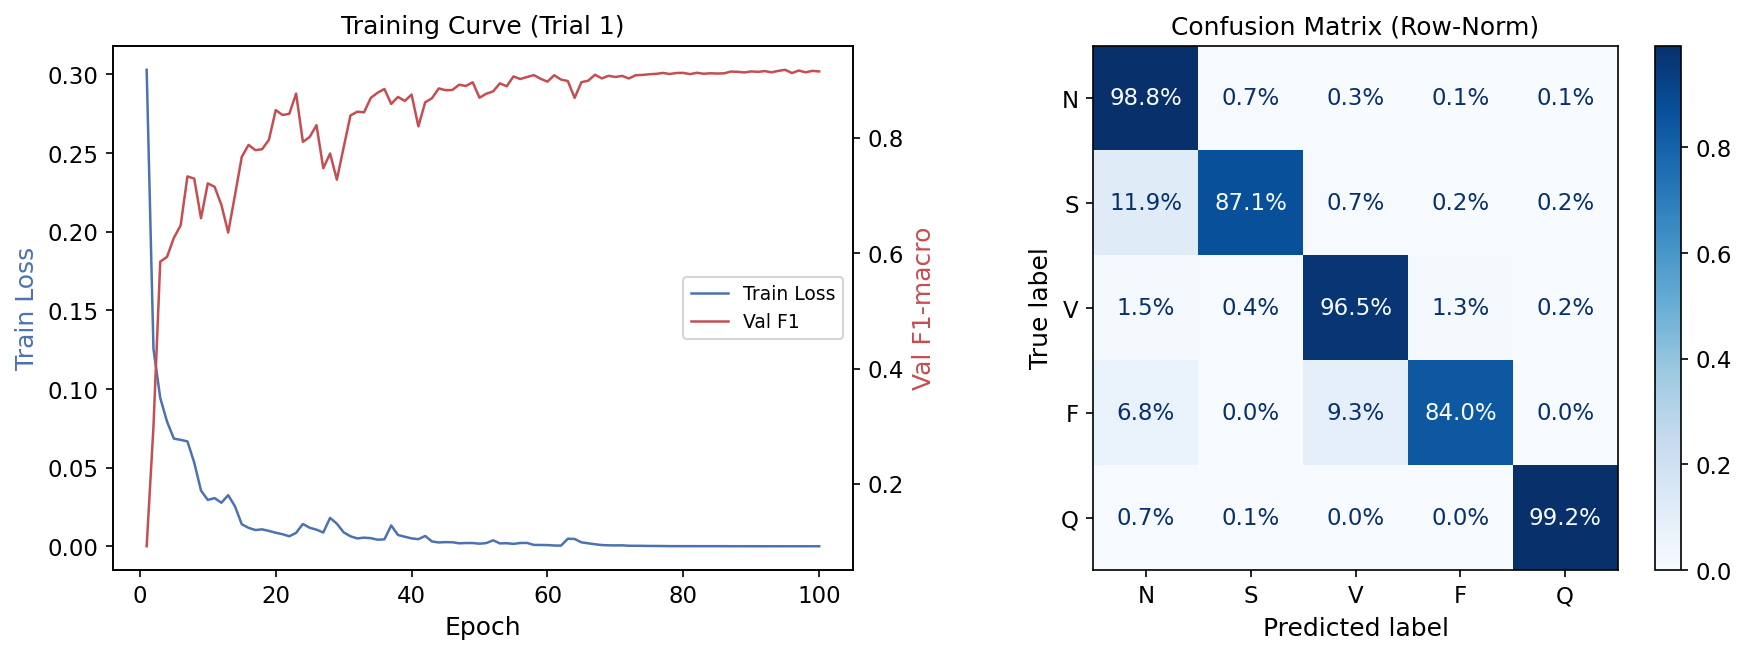

In [15]:
# Phase 1 训练曲线 (trial 0) + 混淆矩阵
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ---- 训练曲线 ----
ax = axes[0]
h = p1['dl_histories'][0]
ep = np.arange(1, len(h['train_loss']) + 1)
ax2 = ax.twinx()
l1, = ax.plot(ep, h['train_loss'], color=C['blue'], lw=1.2, label='Train Loss')
l2, = ax2.plot(ep, h['val_f1'], color=C['red'], lw=1.2, label='Val F1')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss', color=C['blue'])
ax2.set_ylabel('Val F1-macro', color=C['red'])
ax.legend(handles=[l1, l2], loc='center right', fontsize=9)
ax.set_title('Training Curve (Trial 1)')

# ---- 混淆矩阵 ----
ax = axes[1]
cm = np.array(p1['confusion_matrix'])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(cm_norm, display_labels=p1['class_names'])
disp.plot(ax=ax, cmap='Blues', values_format='.1%')
ax.set_title('Confusion Matrix (Row-Norm)')

fig.tight_layout()
save_fig(fig, 'phase1_curve_and_cm.png')
plt.show()

---
## Phase 2: Kernel Size 动力学

Saved: phase2_kernel_dynamics.png


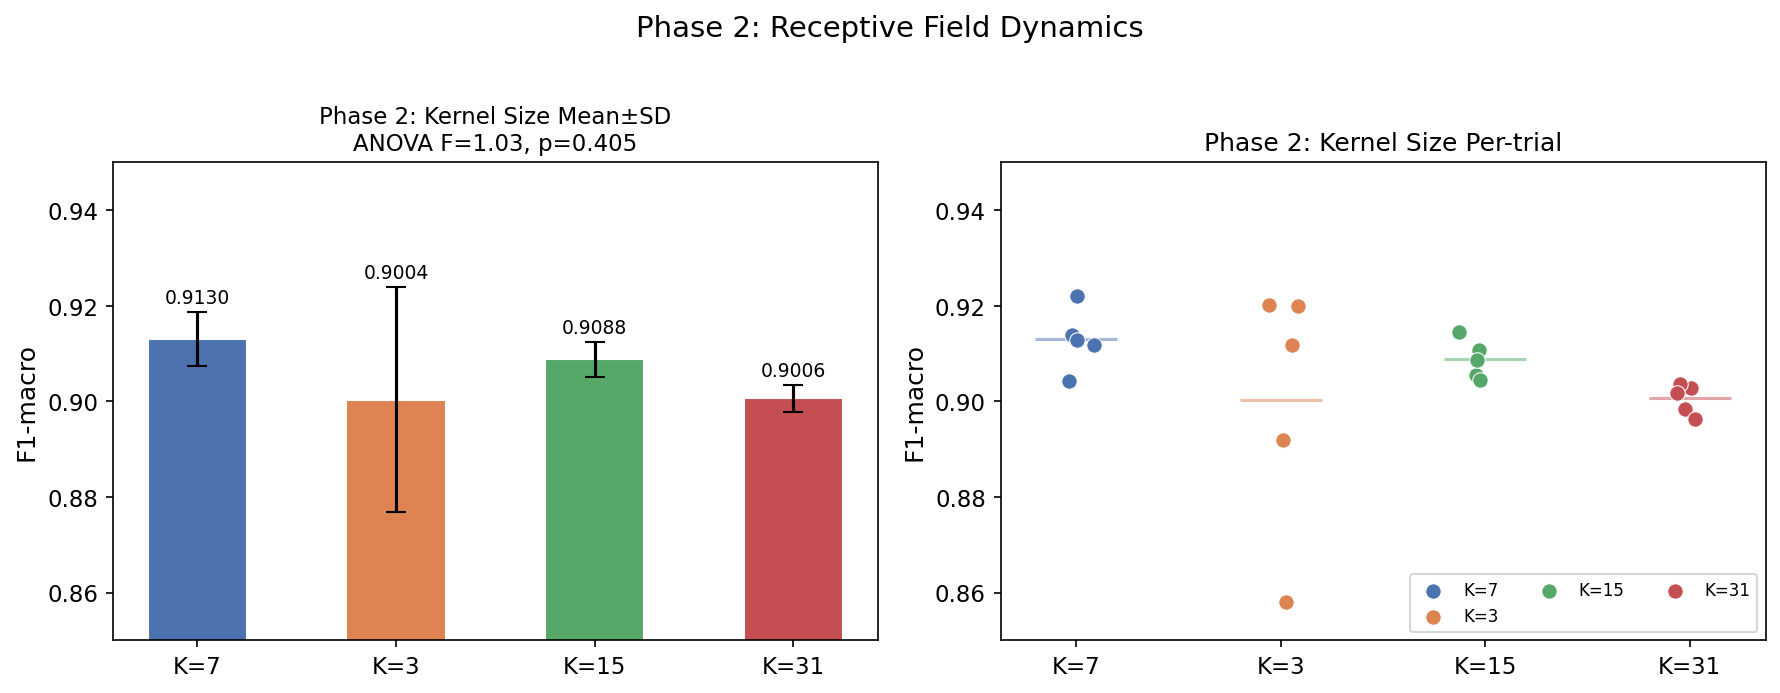

In [16]:
p2 = load_json('phase2_kernel_dynamics.json')

ks = [str(k) for k in p2['kernel_sizes']]
k_names = [f'K={k}' for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bar_scatter(
    axes,
    names=k_names,
    scores_dict={f'K={k}': p2['scores'][k] for k in ks},
    means=[p2['means'][k] for k in ks],
    stds=[p2['stds'][k] for k in ks],
    colors=QUAD,
    title_prefix='Phase 2: Kernel Size',
    ylim=(0.85, 0.95),
    stat_text=f'ANOVA F={p2["anova_f"]:.2f}, p={p2["anova_p"]:.3f}',
)
fig.suptitle('Phase 2: Receptive Field Dynamics', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase2_kernel_dynamics.png')
plt.show()

Saved: phase2_hyper_grid.png


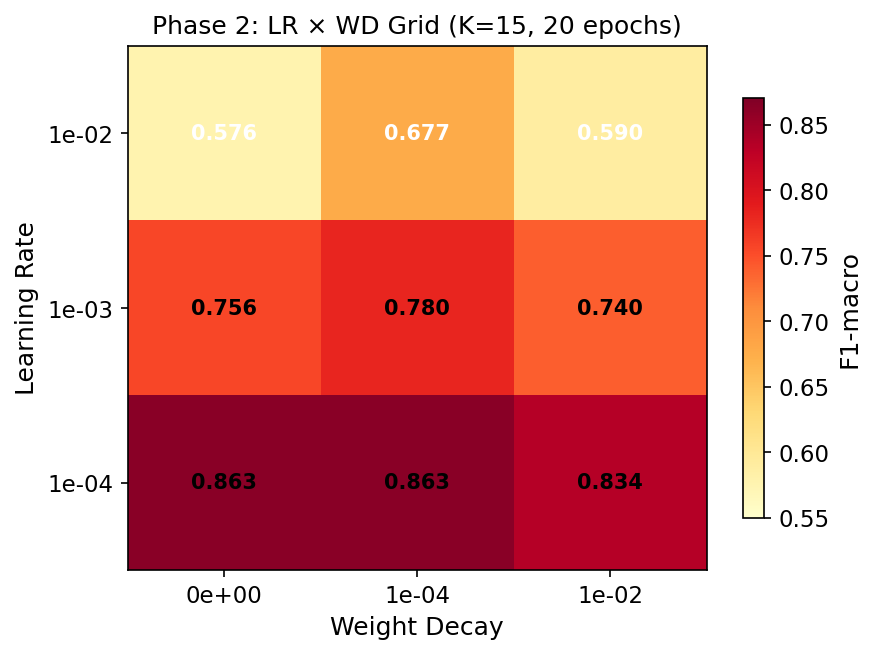

In [17]:
# Phase 2 Task 2.2: LR × Weight Decay 网格搜索热力图
p2g = load_json('phase2_hyper_grid.json')

fig, ax = plt.subplots(figsize=(6, 4.5))
f1 = np.array(p2g['f1_matrix'])
lrs = [f'{lr:.0e}' for lr in p2g['learning_rates']]
wds = [f'{wd:.0e}' for wd in p2g['weight_decays']]

im = ax.imshow(f1, cmap='YlOrRd', aspect='auto', vmin=0.55, vmax=0.87)
ax.set_xticks(np.arange(len(wds))); ax.set_xticklabels(wds)
ax.set_yticks(np.arange(len(lrs))); ax.set_yticklabels(lrs)
ax.set_xlabel('Weight Decay'); ax.set_ylabel('Learning Rate')
ax.set_title('Phase 2: LR × WD Grid (K=15, 20 epochs)')

# 标注数值
for i in range(len(lrs)):
    for j in range(len(wds)):
        val = f1[i, j]
        color = 'white' if val < 0.7 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('F1-macro')
fig.tight_layout()
save_fig(fig, 'phase2_hyper_grid.png')
plt.show()

---
## Phase 3.1: 输入模态对比

Saved: phase3_1_modality.png


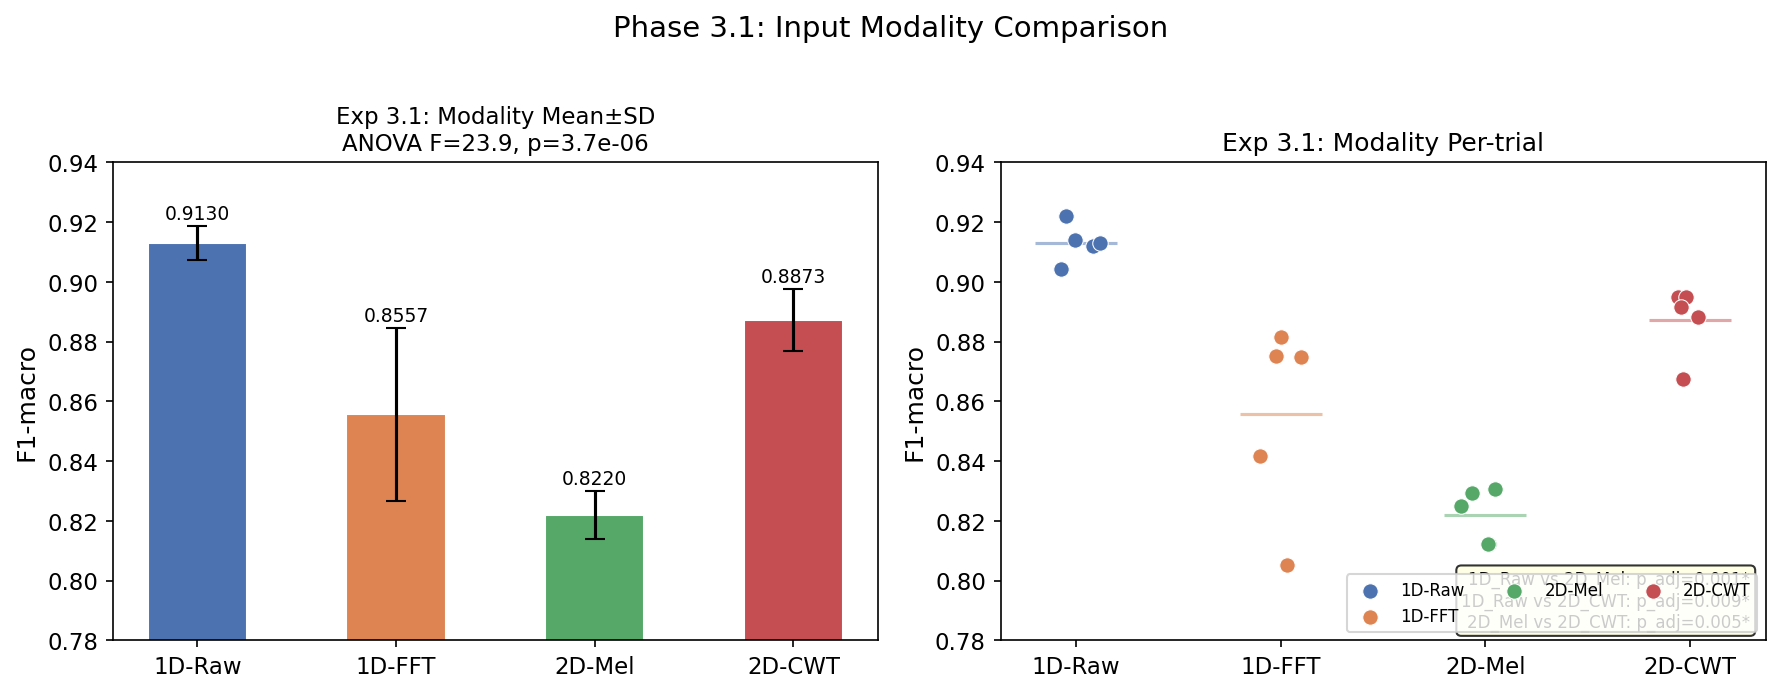

In [18]:
p31 = load_json('phase3_1_modality.json')

# JSON 使用下划线，显示用连字符
mod_keys = ['1D_Raw', '1D_FFT', '2D_Mel', '2D_CWT']
mod_names = ['1D-Raw', '1D-FFT', '2D-Mel', '2D-CWT']
mod_colors = [C['blue'], C['orange'], C['green'], C['red']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bar_scatter(
    axes,
    names=mod_names,
    scores_dict={n: p31['scores'][k] for n, k in zip(mod_names, mod_keys)},
    means=[p31['means'][k] for k in mod_keys],
    stds=[p31['stds'][k] for k in mod_keys],
    colors=mod_colors,
    title_prefix='Exp 3.1: Modality',
    ylim=(0.78, 0.94),
    stat_text=f'ANOVA F={p31["anova_f"]:.1f}, p={p31["anova_p"]:.1e}',
)

# 散点图标注显著配对
sig = [p for p in p31['posthoc'] if p['significant']]
if sig:
    note = '\n'.join([f"{p['pair']}: p_adj={p['p_adj']:.3f}*" for p in sig])
    axes[1].text(0.98, 0.02, note, transform=axes[1].transAxes, fontsize=8,
                 va='bottom', ha='right',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Phase 3.1: Input Modality Comparison', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase3_1_modality.png')
plt.show()

Saved: phase3_1_convergence.png


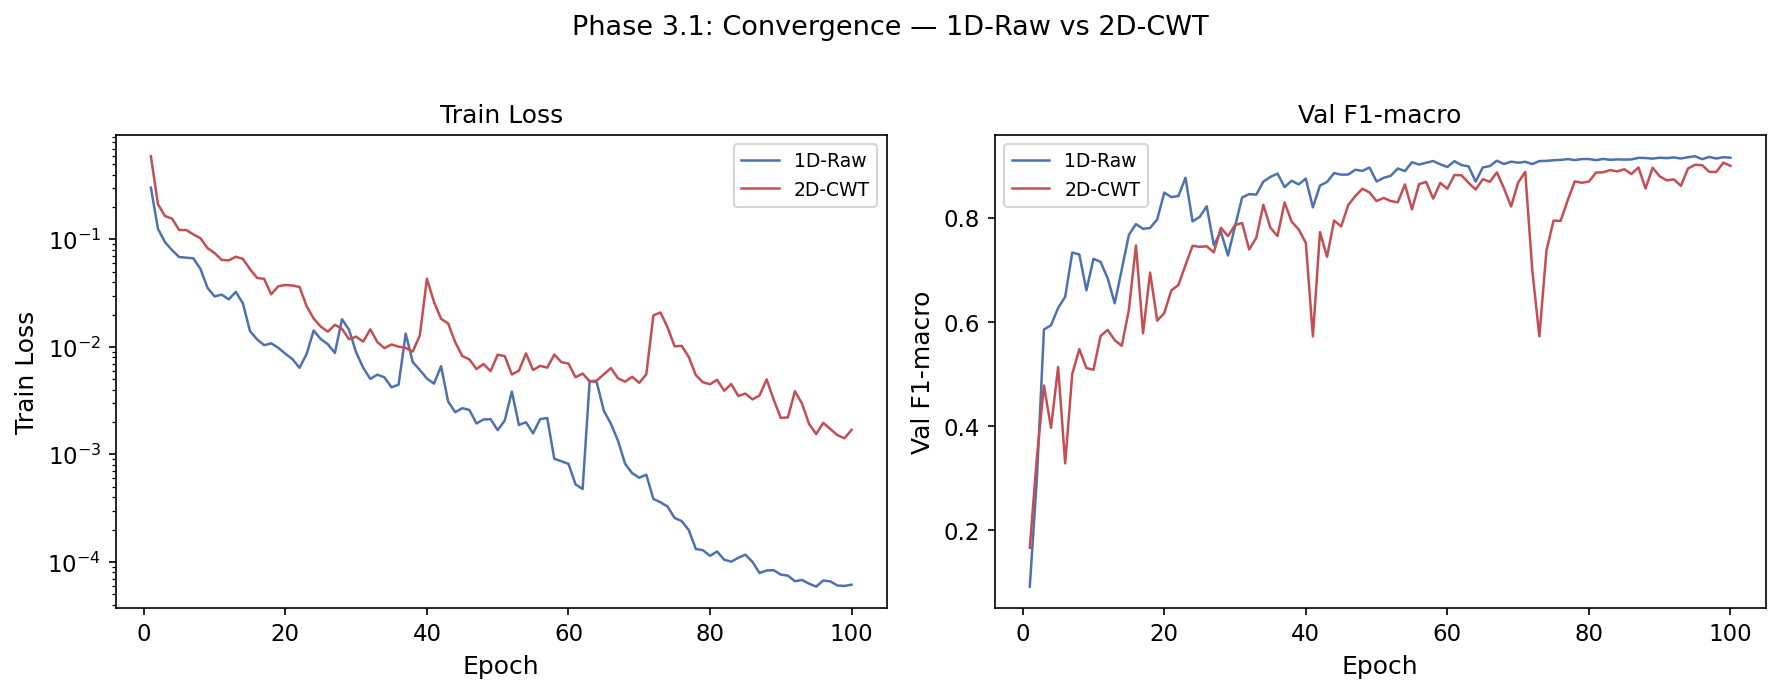

In [19]:
# Phase 3.1: 1D-Raw vs 2D-CWT 收敛对比 (有 histories 的两种模态)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, key, ylabel in [(axes[0], 'train_loss', 'Train Loss'),
                         (axes[1], 'val_f1', 'Val F1-macro')]:
    for mod, color, label in [('1D_Raw', C['blue'], '1D-Raw'),
                               ('2D_CWT', C['red'], '2D-CWT')]:
        h_list = p31['histories'][mod]
        if not h_list or not isinstance(h_list[0], dict): continue
        h = h_list[0]
        ep = np.arange(1, len(h[key]) + 1)
        ax.plot(ep, h[key], color=color, lw=1.2, label=label)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.set_title(ylabel)
    if key == 'train_loss': ax.set_yscale('log')

fig.suptitle('Phase 3.1: Convergence — 1D-Raw vs 2D-CWT', fontsize=13, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase3_1_convergence.png')
plt.show()

---
## Phase 3.2: 架构归纳偏置对比

Saved: phase3_2_architecture.png


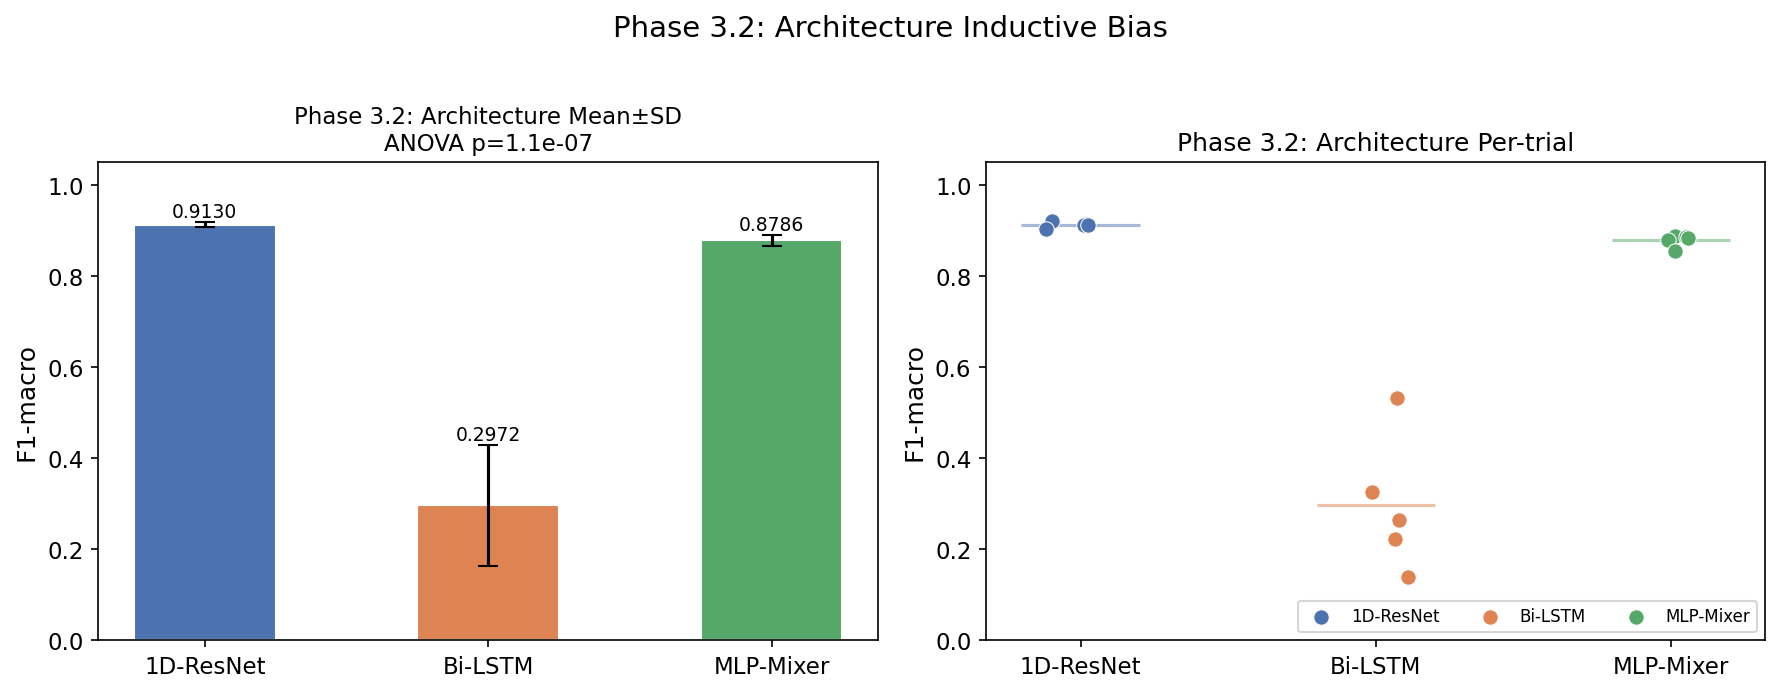

In [20]:
p32 = load_json('phase3_2_bias.json')

arch_names = ['1D-ResNet', 'Bi-LSTM', 'MLP-Mixer']
arch_colors = [C['blue'], C['orange'], C['green']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bar_scatter(
    axes,
    names=arch_names,
    scores_dict={n: p32[n]['f1_scores'] for n in arch_names},
    means=[p32[n]['f1_mean'] for n in arch_names],
    stds=[p32[n]['f1_std'] for n in arch_names],
    colors=arch_colors,
    title_prefix='Phase 3.2: Architecture',
    ylim=(0, 1.05),
    stat_text=f'ANOVA p={p32["anova_p"]:.1e}',
)
fig.suptitle('Phase 3.2: Architecture Inductive Bias', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase3_2_architecture.png')
plt.show()

Saved: phase3_2_efficiency_and_curves.png


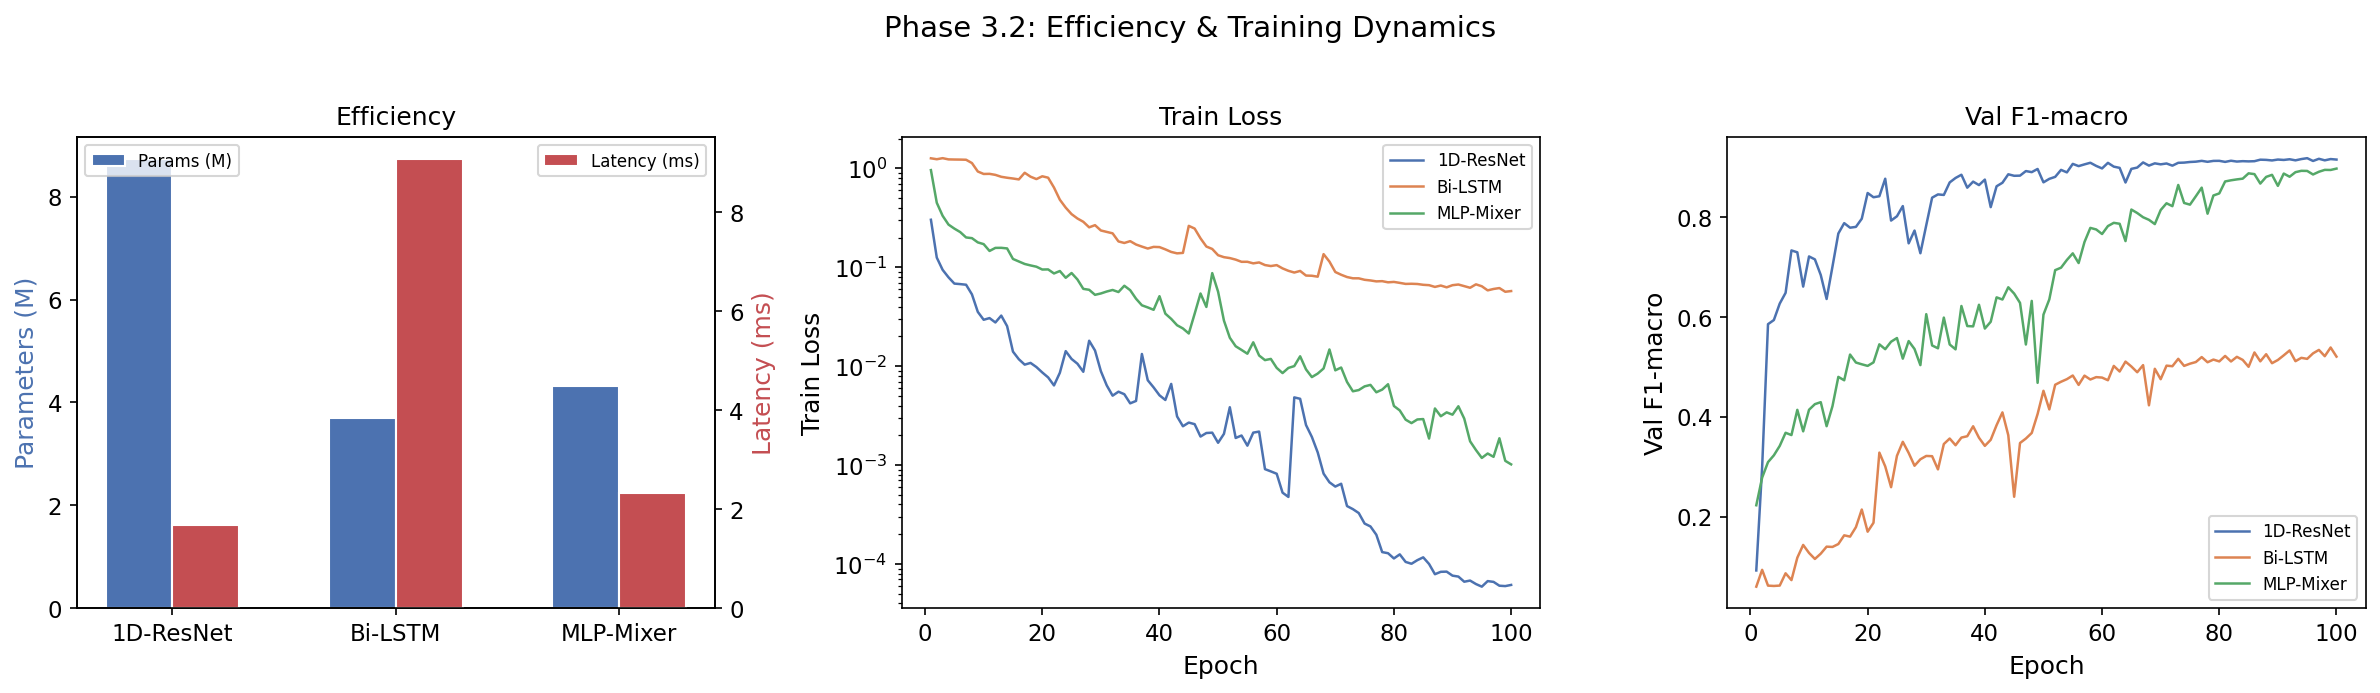

In [21]:
# Phase 3.2 辅助图：参数量 + 推理延迟 + 训练曲线
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ---- (a) 参数量 & 延迟 双轴柱状图 ----
ax = axes[0]
params = [p32[n]['params'] / 1e6 for n in arch_names]
latency = [p32[n]['latency_ms'] for n in arch_names]
x = np.arange(len(arch_names))
w = 0.3
ax.bar(x - w/2, params, w, color=C['blue'], label='Params (M)', edgecolor='white')
ax2 = ax.twinx()
ax2.bar(x + w/2, latency, w, color=C['red'], label='Latency (ms)', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(arch_names)
ax.set_ylabel('Parameters (M)', color=C['blue'])
ax2.set_ylabel('Latency (ms)', color=C['red'])
ax.set_title('Efficiency')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# ---- (b)(c) 训练曲线 ----
histories = p32['histories']
for idx, (ax, key, ylabel) in enumerate([
    (axes[1], 'train_loss', 'Train Loss'),
    (axes[2], 'val_f1', 'Val F1-macro'),
]):
    for name, color in zip(arch_names, arch_colors):
        h_list = histories[name]
        if not h_list or len(h_list[0]) == 0:
            continue
        h = h_list[0]
        ep = np.arange(1, len(h[key]) + 1)
        ax.plot(ep, h[key], color=color, lw=1.2, label=name)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.set_title(ylabel)
    if key == 'train_loss': ax.set_yscale('log')

fig.suptitle('Phase 3.2: Efficiency & Training Dynamics', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase3_2_efficiency_and_curves.png')
plt.show()

---
## Phase 3.3: 分类器解耦

Saved: phase3_3_classifiers.png


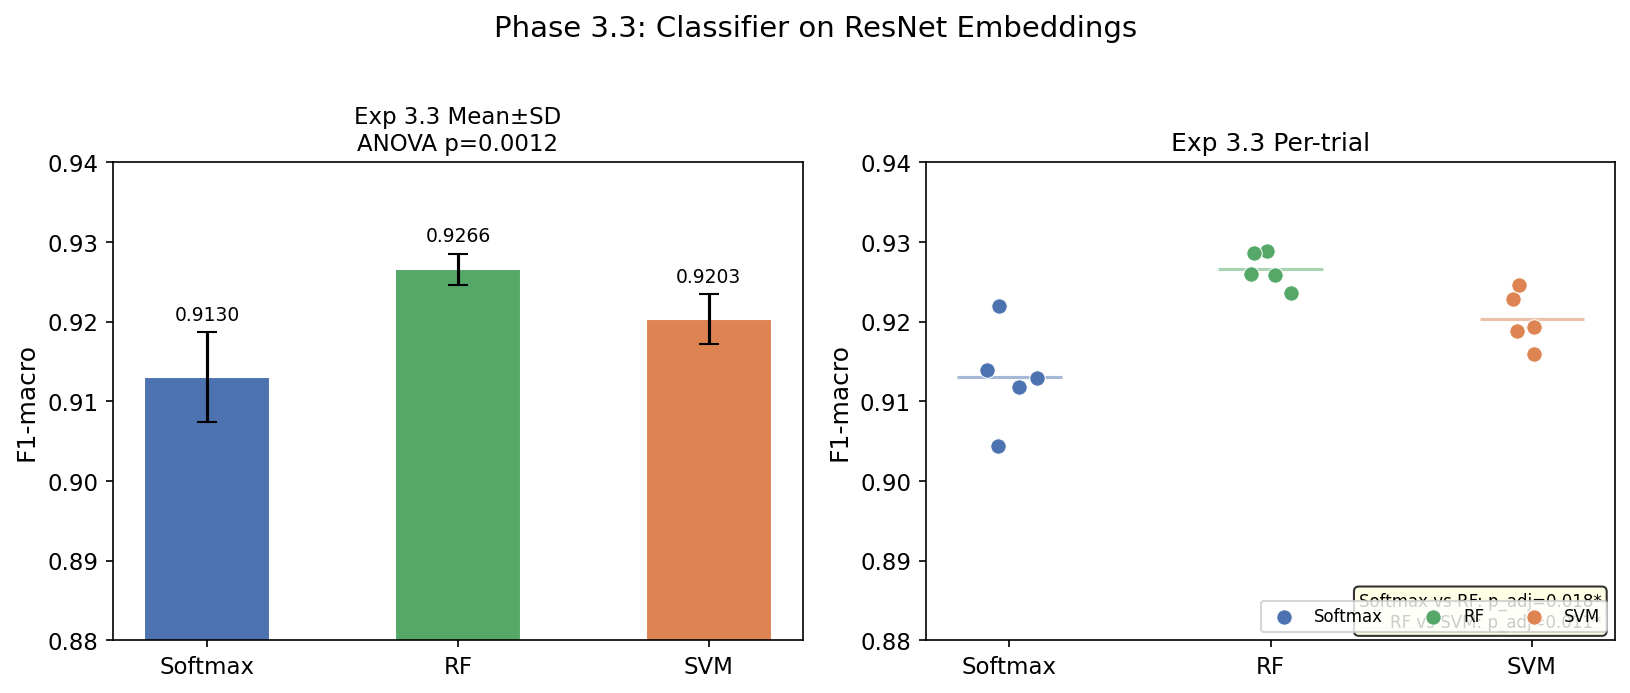

In [22]:
p33 = load_json('phase3_3_classifiers.json')

clf_names = ['Softmax', 'RF', 'SVM']
clf_colors = [C['blue'], C['green'], C['orange']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
bar_scatter(
    axes,
    names=clf_names,
    scores_dict={n: p33['scores'][n] for n in clf_names},
    means=[p33['means'][n] for n in clf_names],
    stds=[p33['stds'][n] for n in clf_names],
    colors=clf_colors,
    title_prefix='Exp 3.3',
    ylim=(0.88, 0.94),
    stat_text=f'ANOVA p={p33["anova_p"]:.4f}',
)

# 散点图右下角标注显著配对
sig = [p for p in p33['posthoc'] if p['significant']]
if sig:
    note = '\n'.join([f"{p['pair']}: p_adj={p['p_adj']:.3f}*" for p in sig])
    axes[1].text(0.98, 0.02, note, transform=axes[1].transAxes, fontsize=8,
                 va='bottom', ha='right',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Phase 3.3: Classifier on ResNet Embeddings', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase3_3_classifiers.png')
plt.show()

---
## Phase 3.4: 数据增强鲁棒性

Saved: phase3_4_augmentation.png


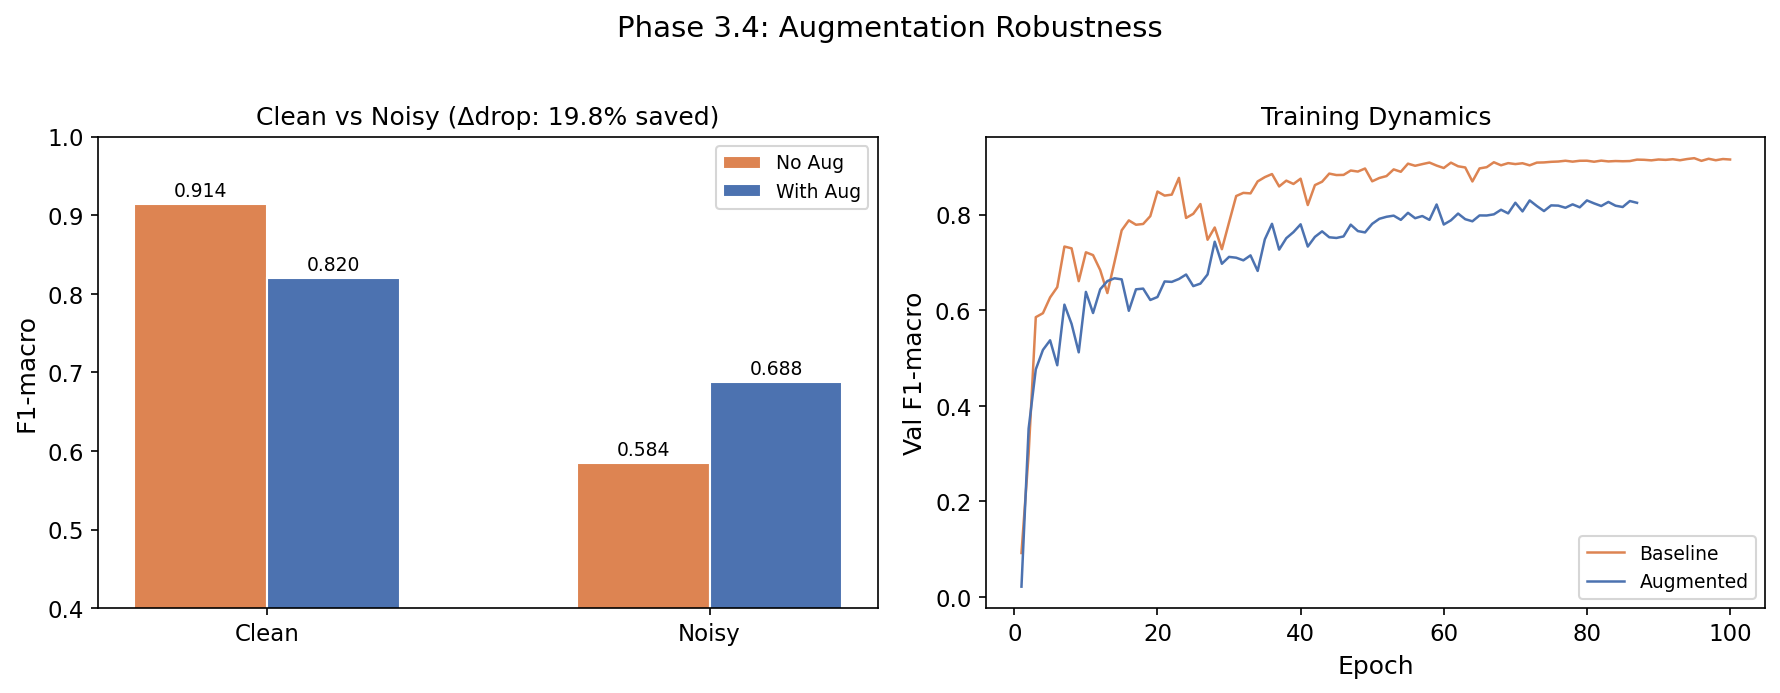

In [23]:
p34 = load_json('phase3_4_augmentation.json')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ---- (a) 分组柱状图 ----
ax = axes[0]
labels = ['Clean', 'Noisy']
baseline = [p34['Baseline_Clean_F1'], p34['Baseline_Noisy_F1']]
augmented = [p34['Augmented_Clean_F1'], p34['Augmented_Noisy_F1']]
x = np.arange(2); w = 0.3
b1 = ax.bar(x - w/2, baseline, w, label='No Aug', color=C['orange'], edgecolor='white')
b2 = ax.bar(x + w/2, augmented, w, label='With Aug', color=C['blue'], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('F1-macro'); ax.set_ylim(0.4, 1.0)
ax.legend(fontsize=9)
ax.set_title(f'Clean vs Noisy (Δdrop: {p34["Baseline_Drop"]-p34["Augmented_Drop"]:.1%} saved)')
for bars, vals in [(b1, baseline), (b2, augmented)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
                ha='center', fontsize=9)

# ---- (b) 训练曲线 ----
ax = axes[1]
for key, color, label in [('baseline_history', C['orange'], 'Baseline'),
                           ('aug_history', C['blue'], 'Augmented')]:
    h = p34[key]
    ep = np.arange(1, len(h['val_f1']) + 1)
    ax.plot(ep, h['val_f1'], color=color, lw=1.2, label=label)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val F1-macro')
ax.set_title('Training Dynamics'); ax.legend(fontsize=9)

fig.suptitle('Phase 3.4: Augmentation Robustness', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase3_4_augmentation.png')
plt.show()

---
## Phase 3.5: R 波对齐漂移鲁棒性

Saved: phase3_5_jitter.png


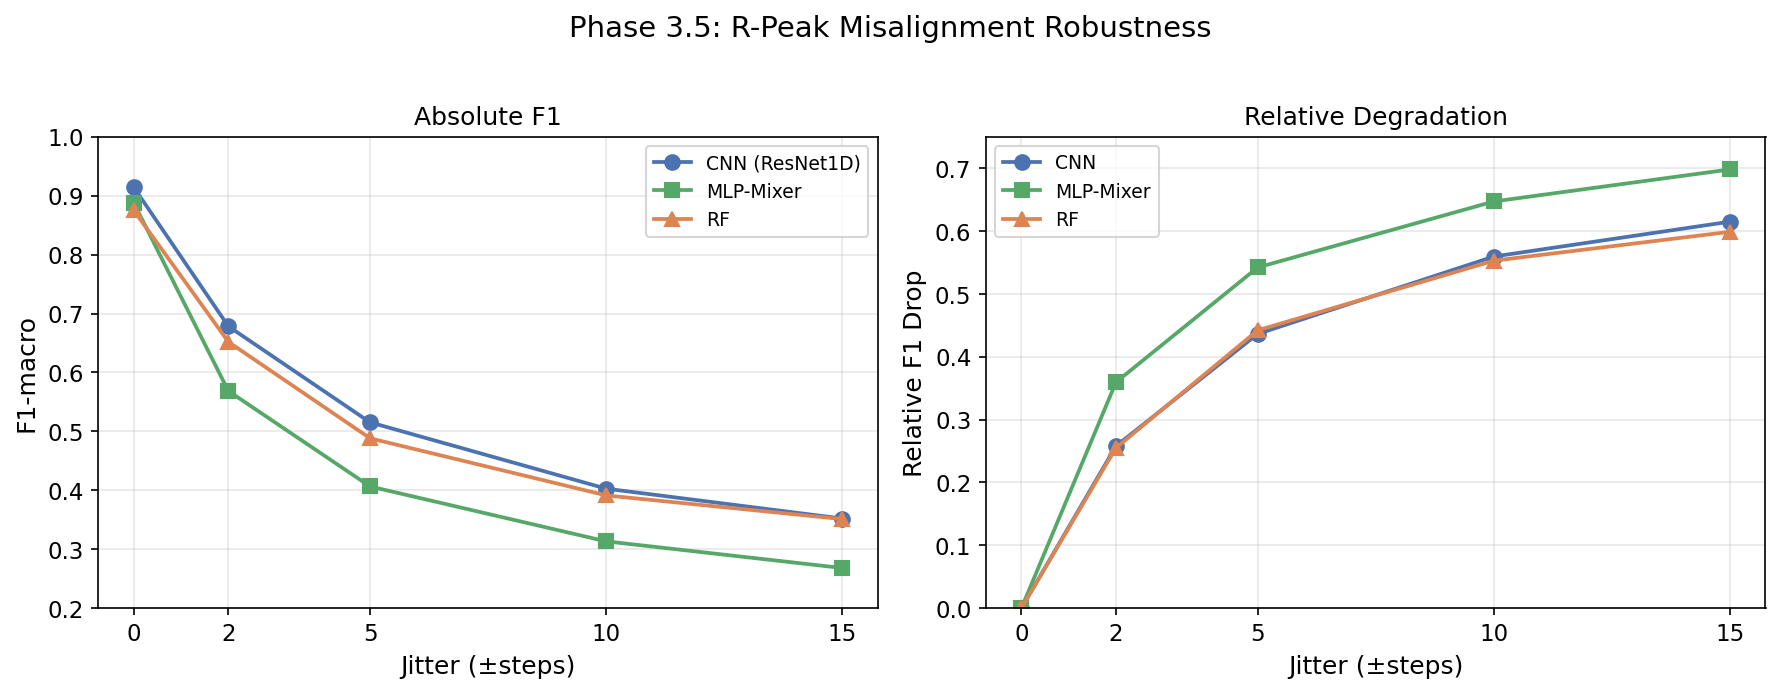

In [24]:
p35 = load_json('phase3_5_jitter_robustness.json')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ---- (a) 绝对 F1 衰减曲线 ----
ax = axes[0]
jitters = p35['jitters']
for key, color, label, marker in [
    ('cnn_scores',   C['blue'],   'CNN (ResNet1D)', 'o'),
    ('mixer_scores', C['green'],  'MLP-Mixer',      's'),
    ('rf_scores',    C['orange'], 'RF',              '^'),
]:
    ax.plot(jitters, p35[key], color=color, marker=marker, lw=1.8,
            markersize=7, label=label)
ax.set_xlabel('Jitter (±steps)'); ax.set_ylabel('F1-macro')
ax.set_ylim(0.2, 1.0); ax.set_xticks(jitters)
ax.legend(fontsize=9); ax.set_title('Absolute F1'); ax.grid(True, alpha=0.3)

# ---- (b) 相对衰减率 ----
ax = axes[1]
for key, color, label, marker in [
    ('cnn_scores',   C['blue'],   'CNN',       'o'),
    ('mixer_scores', C['green'],  'MLP-Mixer', 's'),
    ('rf_scores',    C['orange'], 'RF',        '^'),
]:
    base = p35[key][0]
    drops = [(base - s) / base for s in p35[key]]
    ax.plot(jitters, drops, color=color, marker=marker, lw=1.8, markersize=7, label=label)
ax.set_xlabel('Jitter (±steps)'); ax.set_ylabel('Relative F1 Drop')
ax.set_ylim(0, 0.75); ax.set_xticks(jitters)
ax.legend(fontsize=9); ax.set_title('Relative Degradation'); ax.grid(True, alpha=0.3)

fig.suptitle('Phase 3.5: R-Peak Misalignment Robustness', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase3_5_jitter.png')
plt.show()

---
## Phase 4: SE 注意力 + Grad-CAM

Saved: phase4_se_compare.png


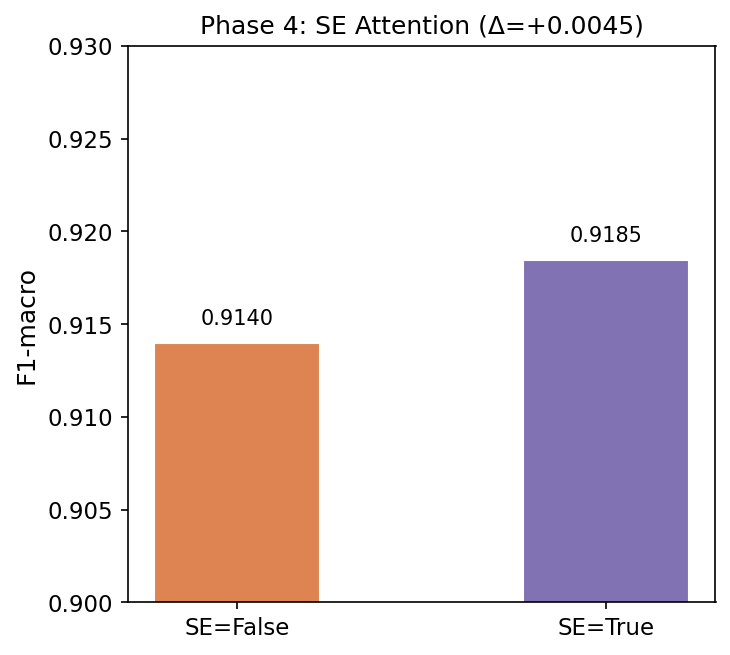

In [25]:
p4 = load_json('phase4_se_gradcam.json')

# SE 对比 — 同样用 柱状图 + 标注
fig, ax = plt.subplots(figsize=(5, 4.5))
labels = ['SE=False', 'SE=True']
f1s = [p4['no_se_f1'], p4['se_f1']]
colors = [C['orange'], C['purple']]
bars = ax.bar(labels, f1s, color=colors, edgecolor='white', width=0.45)
ax.set_ylabel('F1-macro'); ax.set_ylim(0.90, 0.93)
delta = f1s[1] - f1s[0]
ax.set_title(f'Phase 4: SE Attention (Δ={delta:+.4f})')
for bar, v in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}', ha='center', fontsize=10)
fig.tight_layout()
save_fig(fig, 'phase4_se_compare.png')
plt.show()

Saved: phase4_gradcam_atlas.png


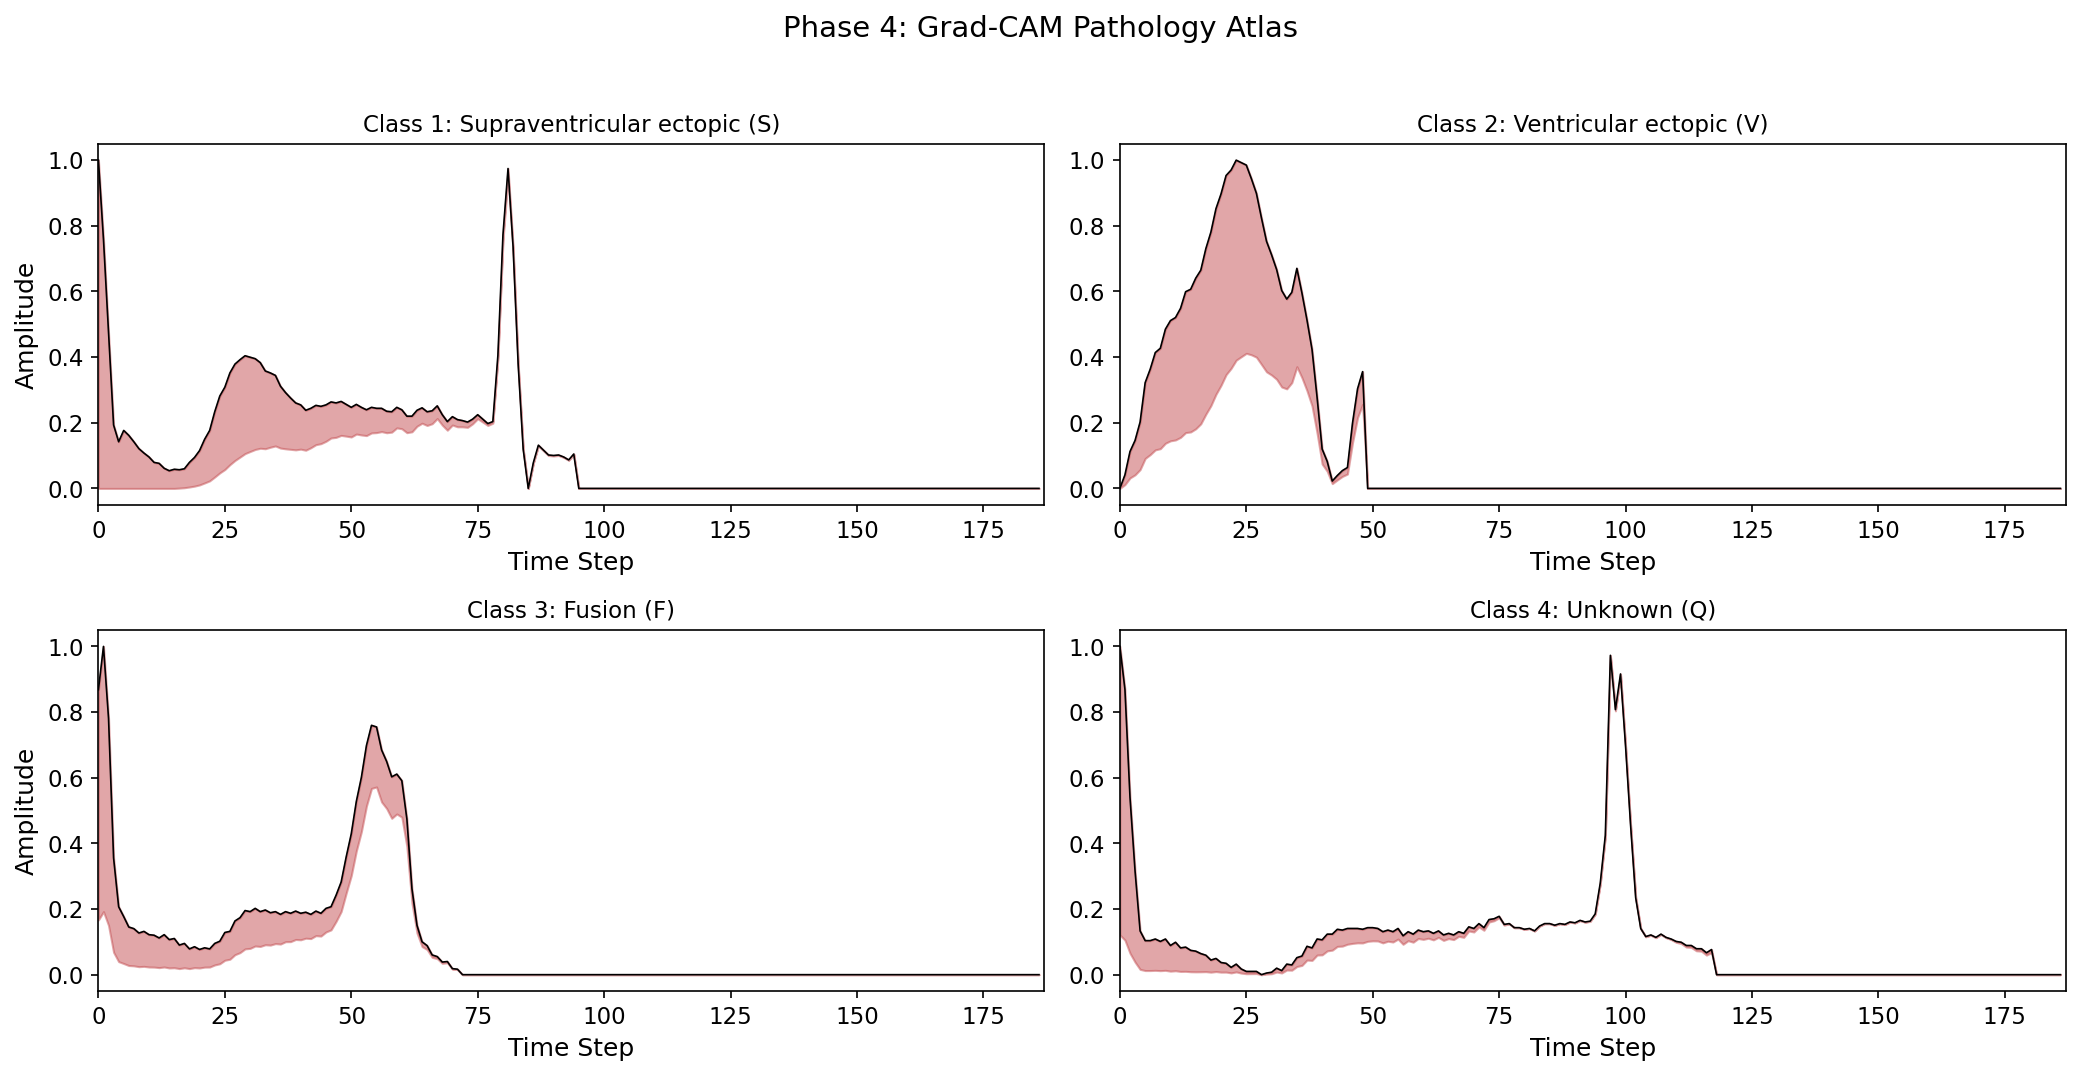

In [26]:
# Grad-CAM 病理图册
atlas = p4['pathology_atlas']

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()

for i, (cls, info) in enumerate(atlas.items()):
    ax = axes[i]
    signal = np.array(info['signal'])
    heatmap = np.array(info['heatmap'])
    x = np.arange(len(signal))

    # 归一化 heatmap
    hm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    ax.plot(x, signal, color='black', lw=0.8)
    ax.fill_between(x, signal, signal * hm, alpha=0.5, color=C['red'])
    ax.set_title(f"Class {cls[-1]}: {info['name']}", fontsize=11)
    ax.set_xlim(0, len(signal))
    ax.set_xlabel('Time Step')
    if i % 2 == 0: ax.set_ylabel('Amplitude')

fig.suptitle('Phase 4: Grad-CAM Pathology Atlas', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase4_gradcam_atlas.png')
plt.show()

---
## Phase 5: SOTA 对比 (InceptionTime vs ResNet1D+SE)

Saved: phase5_sota.png


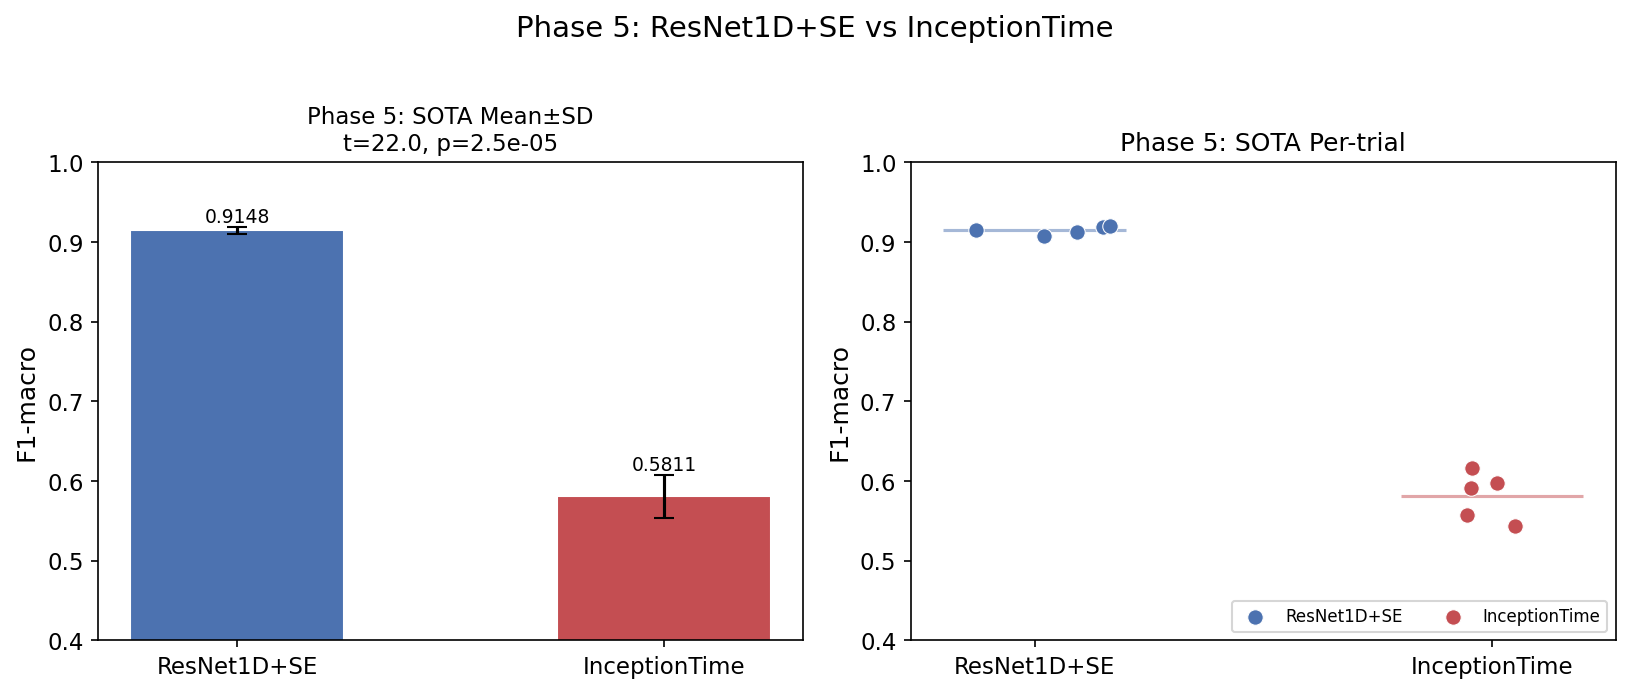

In [27]:
p5 = load_json('phase5_sota_comparison.json')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
bar_scatter(
    axes,
    names=['ResNet1D+SE', 'InceptionTime'],
    scores_dict={'ResNet1D+SE': p5['scores']['ResNet1D'],
                 'InceptionTime': p5['scores']['InceptionTime']},
    means=[p5['means']['ResNet1D'], p5['means']['InceptionTime']],
    stds=[p5['stds']['ResNet1D'], p5['stds']['InceptionTime']],
    colors=[C['blue'], C['red']],
    title_prefix='Phase 5: SOTA',
    ylim=(0.4, 1.0),
    stat_text=f't={p5["t_stat"]:.1f}, p={p5["p_val"]:.1e}',
)
fig.suptitle('Phase 5: ResNet1D+SE vs InceptionTime', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase5_sota.png')
plt.show()

Saved: phase5_convergence.png


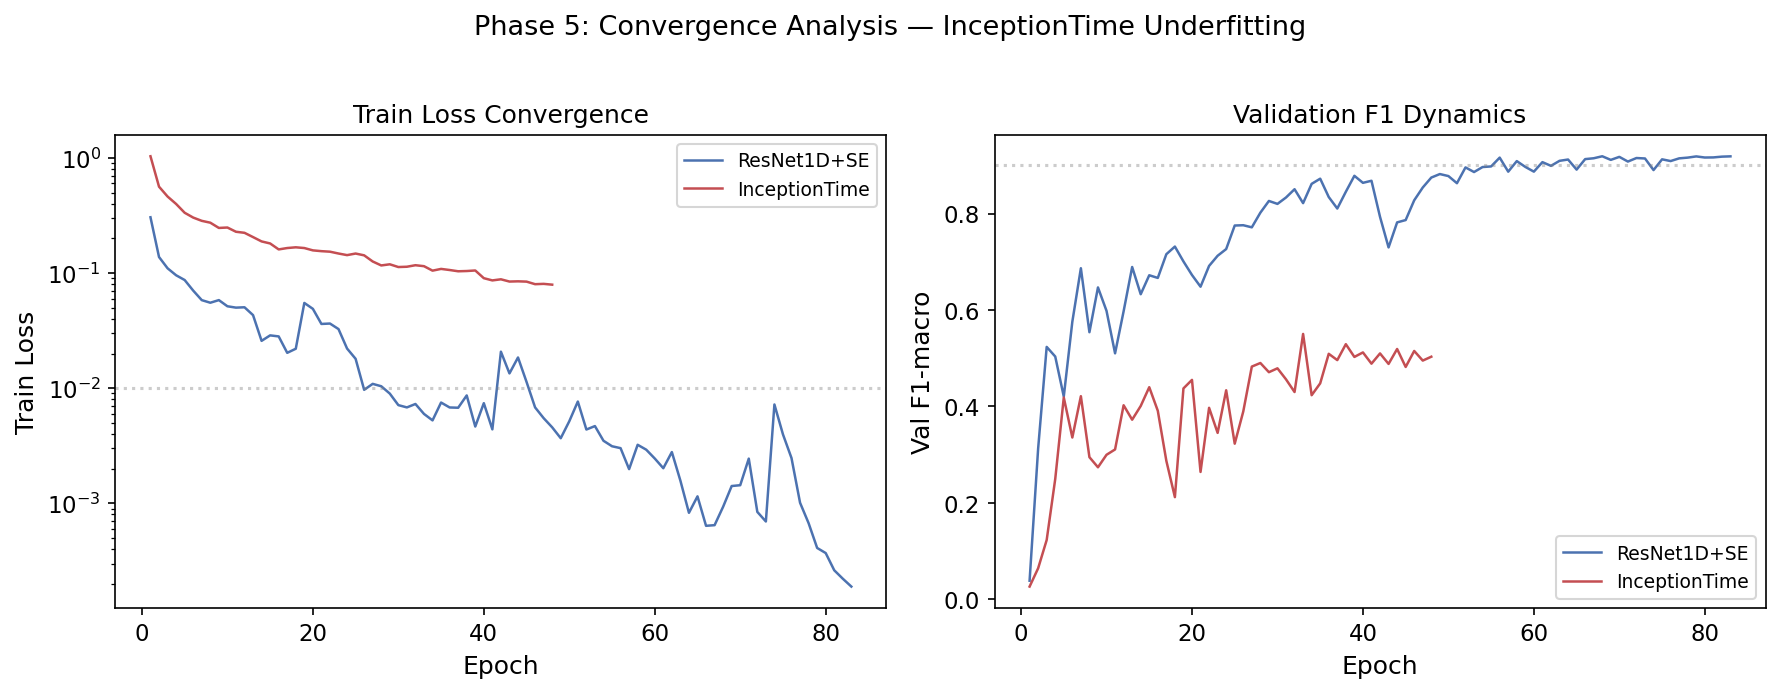

In [28]:
# Phase 5: 收敛动力学对比 — 揭示 InceptionTime 的欠拟合
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ---- (a) Train Loss ----
ax = axes[0]
for arch, color, label in [('ResNet1D', C['blue'], 'ResNet1D+SE'),
                            ('InceptionTime', C['red'], 'InceptionTime')]:
    h_list = p5['histories'][arch]
    h = h_list[0]
    ep = np.arange(1, len(h['train_loss']) + 1)
    ax.plot(ep, h['train_loss'], color=color, lw=1.2, label=label)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss')
ax.set_title('Train Loss Convergence')
ax.set_yscale('log'); ax.legend(fontsize=9)
ax.axhline(0.01, ls=':', color='gray', alpha=0.4)

# ---- (b) Val F1 ----
ax = axes[1]
for arch, color, label in [('ResNet1D', C['blue'], 'ResNet1D+SE'),
                            ('InceptionTime', C['red'], 'InceptionTime')]:
    h_list = p5['histories'][arch]
    h = h_list[0]
    ep = np.arange(1, len(h['val_f1']) + 1)
    ax.plot(ep, h['val_f1'], color=color, lw=1.2, label=label)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val F1-macro')
ax.set_title('Validation F1 Dynamics'); ax.legend(fontsize=9)
ax.axhline(0.90, ls=':', color='gray', alpha=0.4)

fig.suptitle('Phase 5: Convergence Analysis — InceptionTime Underfitting', fontsize=13, y=1.02)
fig.tight_layout()
save_fig(fig, 'phase5_convergence.png')
plt.show()

---
## 总结: 全局 F1 对比总览

Saved: summary_overall.png


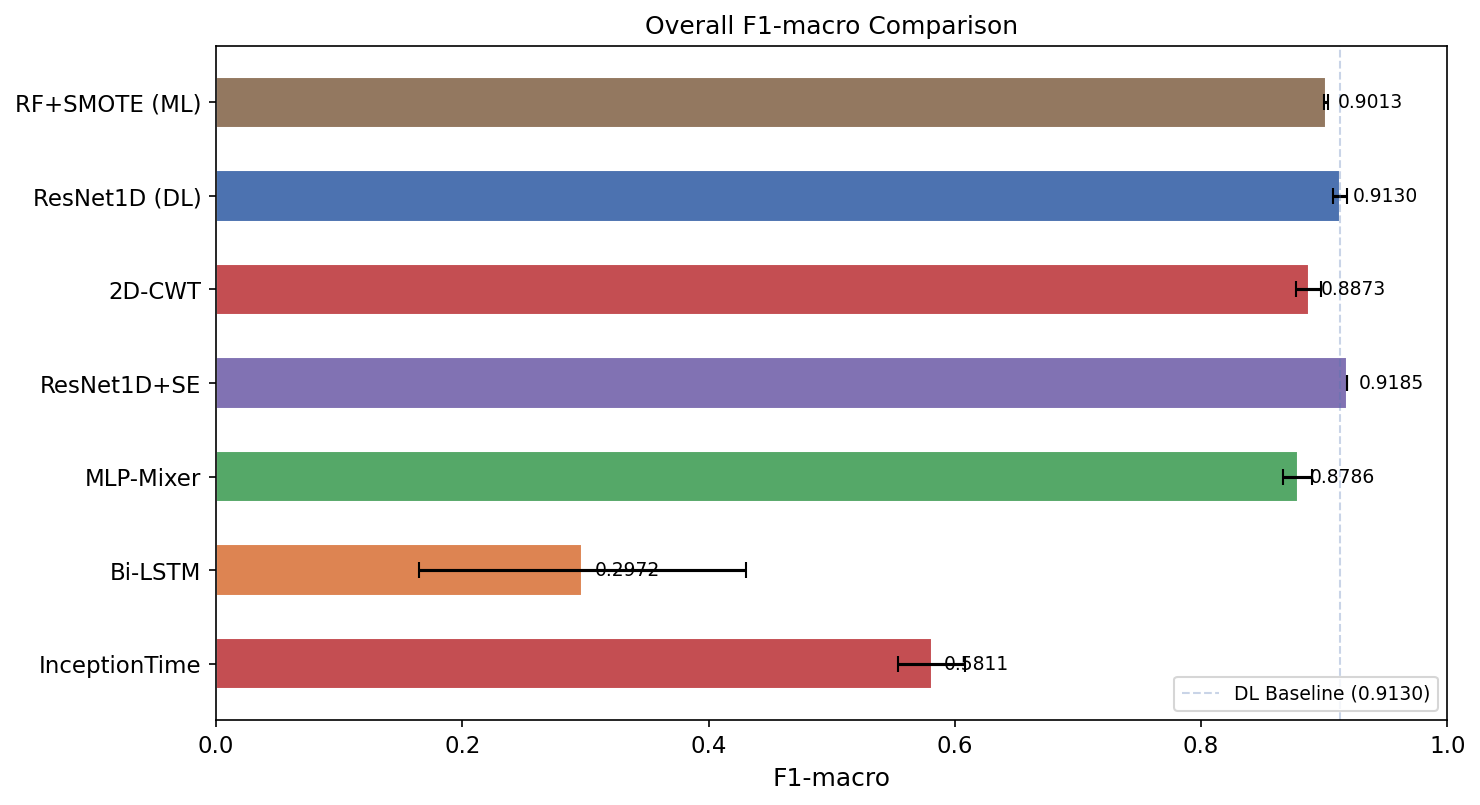

In [29]:
fig, ax = plt.subplots(figsize=(10, 5.5))

summary = [
    ('RF+SMOTE (ML)',   p1['ml_mean'],                  p1['ml_std'],                  C['gray']),
    ('ResNet1D (DL)',   p1['dl_mean'],                  p1['dl_std'],                  C['blue']),
    ('2D-CWT',          p31['means']['2D_CWT'],          p31['stds']['2D_CWT'],         C['red']),
    ('ResNet1D+SE',     p4['se_f1'],                    0,                             C['purple']),
    ('MLP-Mixer',       p32['MLP-Mixer']['f1_mean'],    p32['MLP-Mixer']['f1_std'],    C['green']),
    ('Bi-LSTM',         p32['Bi-LSTM']['f1_mean'],      p32['Bi-LSTM']['f1_std'],      C['orange']),
    ('InceptionTime',   p5['means']['InceptionTime'],   p5['stds']['InceptionTime'],   C['red']),
]

names  = [s[0] for s in summary]
means  = [s[1] for s in summary]
stds   = [s[2] for s in summary]
colors = [s[3] for s in summary]

bars = ax.barh(names, means, xerr=stds, capsize=4,
               color=colors, edgecolor='white', height=0.55)
ax.set_xlabel('F1-macro'); ax.set_xlim(0, 1.0)
ax.axvline(p1['dl_mean'], ls='--', color=C['blue'], alpha=0.3, lw=1,
           label=f'DL Baseline ({p1["dl_mean"]:.4f})')
ax.invert_yaxis()
ax.set_title('Overall F1-macro Comparison')
for bar, m in zip(bars, means):
    ax.text(m + 0.01, bar.get_y() + bar.get_height()/2,
            f'{m:.4f}', va='center', fontsize=9)
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
save_fig(fig, 'summary_overall.png')
plt.show()

In [30]:
print('All figures saved to:', FIG_DIR.resolve())
print('Files:', sorted(os.listdir(FIG_DIR)))

All figures saved to: /Data5/ddf/projects/2026sp_MLAI/hw_2/results/figures
Files: ['phase1_bars_and_curve.png', 'phase1_bars_and_scatter.png', 'phase1_confusion_matrix.png', 'phase1_curve_and_cm.png', 'phase2_hyper_grid.png', 'phase2_kernel_dynamics.png', 'phase3_1_convergence.png', 'phase3_1_modality.png', 'phase3_2_architecture.png', 'phase3_2_efficiency_and_curves.png', 'phase3_2_training_curves.png', 'phase3_3_classifiers.png', 'phase3_3_scatter.png', 'phase3_4_augmentation.png', 'phase3_5_jitter.png', 'phase4_gradcam_atlas.png', 'phase4_se_compare.png', 'phase5_convergence.png', 'phase5_sota.png', 'summary_overall.png']
